In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install rasterio geopandas matplotlib folium pymannkendall


In [4]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# File path from Google Drive
raster_path = "/content/drive/MyDrive/Chamrajnagar_GeoAI/NDVI_Change_2019_2023.tif"

# Open raster
src = rasterio.open(raster_path)

# Read first band
ndvi_change = src.read(1)

# Basic information
print("Raster Shape:", ndvi_change.shape)
print("CRS:", src.crs)
print("Resolution:", src.res)

Raster Shape: (8012, 15321)
CRS: EPSG:4326
Resolution: (8.983152841195215e-05, 8.983152841195215e-05)


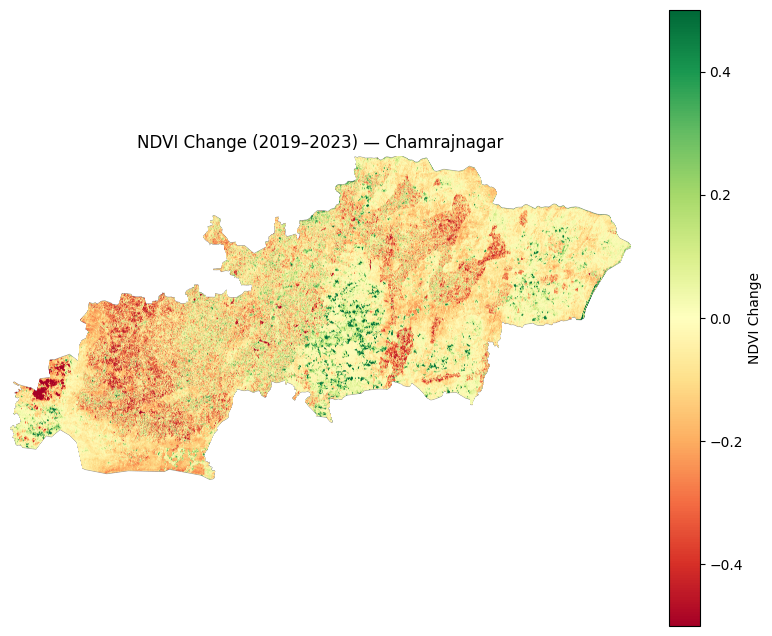

In [7]:
# Plot NDVI Change Raster

plt.figure(figsize=(10, 8))

img = plt.imshow(
    ndvi_change,
    cmap='RdYlGn',
    vmin=-0.5,
    vmax=0.5
)

# Colorbar
plt.colorbar(img, label='NDVI Change')

# Title
plt.title('NDVI Change (2019–2023) — Chamrajnagar')

# Remove axes
plt.axis('off')

plt.show()

In [8]:
# Remove invalid values if present
ndvi_clean = np.where(
    np.isfinite(ndvi_change),
    ndvi_change,
    np.nan
)

# Calculate statistics
print("Minimum NDVI Change :", np.nanmin(ndvi_clean))
print("Maximum NDVI Change :", np.nanmax(ndvi_clean))
print("Mean NDVI Change    :", np.nanmean(ndvi_clean))
print("Std Deviation       :", np.nanstd(ndvi_clean))

Minimum NDVI Change : -1.3902432
Maximum NDVI Change : 1.2381028
Mean NDVI Change    : -0.0608585
Std Deviation       : 0.16297643


In [9]:
# Create masks

increase_mask = ndvi_clean > 0.15
decrease_mask = ndvi_clean < -0.15
stable_mask = (ndvi_clean >= -0.15) & (ndvi_clean <= 0.15)

# Count pixels
increase_pixels = np.sum(increase_mask)
decrease_pixels = np.sum(decrease_mask)
stable_pixels = np.sum(stable_mask)

# Total valid pixels
total_pixels = increase_pixels + decrease_pixels + stable_pixels

# Percentages
increase_percent = (increase_pixels / total_pixels) * 100
decrease_percent = (decrease_pixels / total_pixels) * 100
stable_percent = (stable_pixels / total_pixels) * 100

# Print results
print(f"Vegetation Increase : {increase_percent:.2f}%")
print(f"Vegetation Decrease : {decrease_percent:.2f}%")
print(f"Stable Area         : {stable_percent:.2f}%")

Vegetation Increase : 7.10%
Vegetation Decrease : 22.59%
Stable Area         : 70.31%


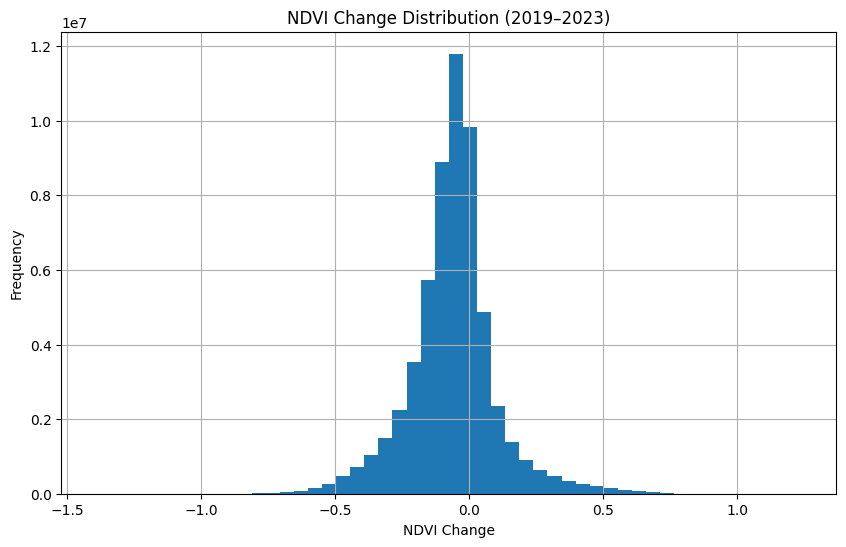

In [18]:
# Flatten raster values
values = ndvi_clean.flatten()

# Remove NaN values
values = values[~np.isnan(values)]

# Plot histogram
plt.figure(figsize=(10,6))

plt.hist(
    values,
    bins=50
)

# Labels
plt.title('NDVI Change Distribution (2019–2023)')
plt.xlabel('NDVI Change')
plt.ylabel('Frequency')

plt.grid(True)

plt.savefig(
    '/content/drive/MyDrive/Chamrajnagar_GeoAI/NDVI Change Distribution (2019–2023).png',
    dpi=300,
    bbox_inches='tight'
)


plt.show()

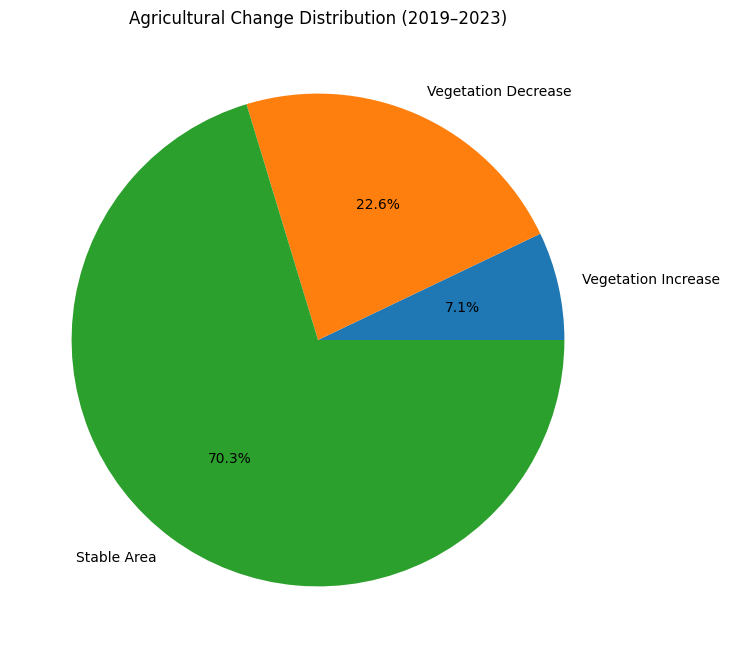

In [17]:
# Data
labels = [
    'Vegetation Increase',
    'Vegetation Decrease',
    'Stable Area'
]

sizes = [
    increase_percent,
    decrease_percent,
    stable_percent
]

# Plot pie chart
plt.figure(figsize=(8,8))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%'
)

# Title
plt.title('Agricultural Change Distribution (2019–2023)')

plt.savefig(
    '/content/drive/MyDrive/Chamrajnagar_GeoAI/Agricultural Change Distribution (2019–2023).png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [12]:
# Area per pixel in hectares
pixel_area_ha = 0.01

# Calculate areas
increase_area = increase_pixels * pixel_area_ha
decrease_area = decrease_pixels * pixel_area_ha
stable_area = stable_pixels * pixel_area_ha

# Print results
print(f"Vegetation Increase Area : {increase_area:.2f} hectares")
print(f"Vegetation Decrease Area : {decrease_area:.2f} hectares")
print(f"Stable Area              : {stable_area:.2f} hectares")

Vegetation Increase Area : 41297.76 hectares
Vegetation Decrease Area : 131417.57 hectares
Stable Area              : 409083.88 hectares


In [13]:
import pandas as pd

# Create summary table
summary_df = pd.DataFrame({
    'Category': [
        'Vegetation Increase',
        'Vegetation Decrease',
        'Stable Area'
    ],

    'Percentage (%)': [
        increase_percent,
        decrease_percent,
        stable_percent
    ],

    'Area (hectares)': [
        increase_area,
        decrease_area,
        stable_area
    ]
})

# Round values
summary_df = summary_df.round(2)

# Display table
summary_df

,Category,Percentage (%),Area (hectares)
0,Vegetation Increase,7.10,41297.76
1,Vegetation Decrease,22.59,131417.57
2,Stable Area,70.31,409083.88


In [14]:
# Save summary table as CSV

summary_df.to_csv(
    '/content/drive/MyDrive/Chamrajnagar_GeoAI/agricultural_change_summary.csv',
    index=False
)

print("CSV file saved successfully")

CSV file saved successfully


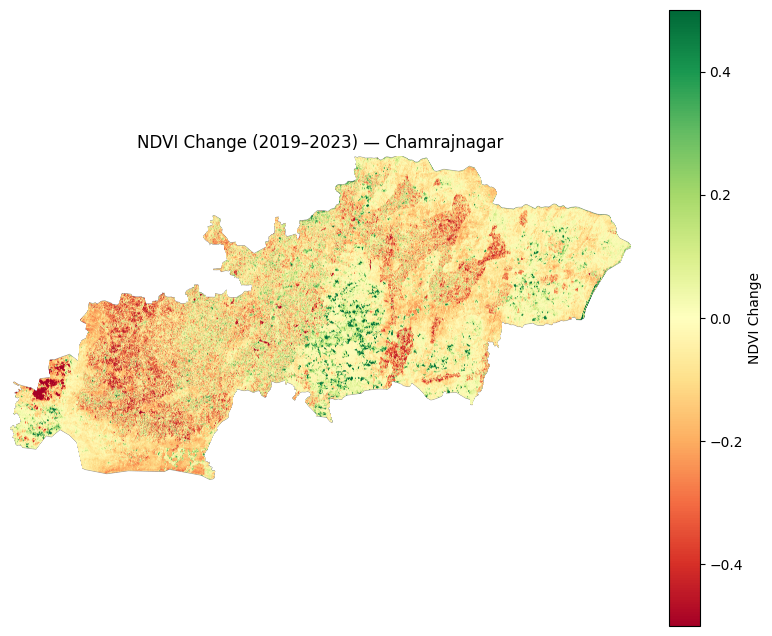

NDVI Change Map saved successfully


In [15]:
# Create figure
plt.figure(figsize=(10, 8))

img = plt.imshow(
    ndvi_change,
    cmap='RdYlGn',
    vmin=-0.5,
    vmax=0.5
)

# Colorbar
plt.colorbar(img, label='NDVI Change')

# Title
plt.title('NDVI Change (2019–2023) — Chamrajnagar')

# Remove axes
plt.axis('off')

# Save figure
plt.savefig(
    '/content/drive/MyDrive/Chamrajnagar_GeoAI/NDVI_Change_Map.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("NDVI Change Map saved successfully")

In [16]:
# Automatic interpretation

if increase_percent > decrease_percent:
    trend = "overall vegetation improvement"
else:
    trend = "overall vegetation degradation"

print("--------------------------------------------------")
print("AGRICULTURAL CHANGE INTERPRETATION")
print("--------------------------------------------------")

print(f"The study indicates {trend} in Chamrajnagar district between 2019 and 2023.")

print(f"\nVegetation increase was observed over {increase_percent:.2f}% "
      f"({increase_area:.2f} hectares) of the district.")

print(f"\nVegetation decrease was observed over {decrease_percent:.2f}% "
      f"({decrease_area:.2f} hectares) of the district.")

print(f"\nStable vegetation conditions were observed over {stable_percent:.2f}% "
      f"({stable_area:.2f} hectares) of the district.")

print("\nThe NDVI-based GeoAI analysis highlights spatial variability in "
      "agricultural and vegetation dynamics across the district.")

--------------------------------------------------
AGRICULTURAL CHANGE INTERPRETATION
--------------------------------------------------
The study indicates overall vegetation degradation in Chamrajnagar district between 2019 and 2023.

Vegetation increase was observed over 7.10% (41297.76 hectares) of the district.

Vegetation decrease was observed over 22.59% (131417.57 hectares) of the district.

Stable vegetation conditions were observed over 70.31% (409083.88 hectares) of the district.

The NDVI-based GeoAI analysis highlights spatial variability in agricultural and vegetation dynamics across the district.


In [19]:
import pandas as pd

# Load CSV
df = pd.read_csv(
    "/content/drive/MyDrive/Chamrajnagar_GeoAI/Yearly_NDVI_Stats.csv"
)

# Display table
df

,system:index,mean_ndvi,year,.geo
0,0,0.631440,2019,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,1,0.616909,2020,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,2,0.547338,2021,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,3,0.599329,2022,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,4,0.570555,2023,"{""type"":""MultiPoint"",""coordinates"":[]}"


In [20]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Prepare data

X = df[['year']]          # Feature
y = df['mean_ndvi']       # Target

# Create model
model = LinearRegression()

# Train model
model.fit(X, y)

print("Model trained successfully")

Model trained successfully


In [21]:
# Predict NDVI for future year

future_year = np.array([[2024]])

predicted_ndvi = model.predict(future_year)

print(f"Predicted Mean NDVI for 2024 : {predicted_ndvi[0]:.4f}")

Predicted Mean NDVI for 2024 : 0.5513


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
